In [1]:
import requests
import pandas as pd
import time

BASE_URL = "https://ourparks.org.uk/api/events"

all_items = []
url = BASE_URL
page = 0

print("Fetching pages...")

while url:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    data = response.json()

    items = data.get("items", [])
    next_url = data.get("next")
    
    page += 1
    print(f"  Page {page}: {len(items)} items")

    if not items or next_url == url:
        break

    all_items.extend(items)
    url = next_url
    time.sleep(0.2)

print(f"\nTotal raw items: {len(all_items)}")

# ── Flatten ────────────────────────────────────────────────────────────────
records = []

for item in all_items:
    state = item.get("state")
    if state == "deleted" or not item.get("data"):
        continue

    d = item["data"]
    loc = d.get("location", {})
    addr = loc.get("address", {})
    geo = loc.get("geo", {})
    activity = d.get("activity", [{}])
    prog = d.get("programme", {})
    leader = d.get("leader", [{}])

    records.append({
        "id":                 item.get("id"),
        "name":               d.get("name"),
        "start_date":         d.get("startDate"),
        "end_date":           d.get("endDate"),
        "duration":           d.get("duration"),
        "activity":           activity[0].get("prefLabel") if activity else None,
        "level":              ", ".join(d.get("level", [])),
        "max_capacity":       d.get("maximumAttendeeCapacity"),
        "remaining_capacity": d.get("remainingAttendeeCapacity"),
        "is_free":            d.get("isAccessibleForFree"),
        "meeting_point":      d.get("meetingPoint"),
        "url":                d.get("url"),
        "location_name":      loc.get("name"),
        "postcode":           addr.get("postalCode"),
        "locality":           addr.get("addressLocality"),
        "region":             addr.get("addressRegion"),
        "country":            addr.get("addressCountry"),
        "latitude":           geo.get("latitude"),
        "longitude":          geo.get("longitude"),
        "programme":          prog.get("name"),
        "programme_url":      prog.get("url"),
        "leader_name":        leader[0].get("name") if leader else None,
    })

df = pd.DataFrame(records)
df["start_date"] = pd.to_datetime(df["start_date"], utc=True, errors="coerce")
df["end_date"]   = pd.to_datetime(df["end_date"],   utc=True, errors="coerce")

# ── Filter: London & boroughs only ────────────────────────────────────────
# London postcodes start with E, EC, N, NW, SE, SW, W, WC, plus BR, CR, DA,
# EN, HA, IG, KT, RM, SM, TW, UB, WD (Greater London outward codes)
LONDON_POSTCODE_PREFIXES = (
    "E", "EC", "N", "NW", "SE", "SW", "W", "WC",
    "BR", "CR", "DA", "EN", "HA", "IG", "KT", "RM", "SM", "TW", "UB", "WD"
)

LONDON_LOCALITIES = (
    "london", "greater london", "city of london"
)

LONDON_BOROUGH_KEYWORDS = (
    "london", "hackney", "lambeth", "southwark", "islington", "camden",
    "tower hamlets", "newham", "lewisham", "brent", "ealing", "haringey",
    "croydon", "barnet", "wandsworth", "greenwich", "hammersmith",
    "kensington", "chelsea", "westminster", "bromley", "sutton", "merton",
    "kingston", "richmond", "hounslow", "hillingdon", "harrow", "waltham",
    "redbridge", "havering", "barking", "dagenham", "enfield", "hertsmere"
)

def is_london(row):
    # 1. Match by postcode prefix
    postcode = str(row.get("postcode") or "").upper().strip()
    if any(postcode.startswith(p) for p in LONDON_POSTCODE_PREFIXES):
        return True

    # 2. Match by locality field
    locality = str(row.get("locality") or "").lower()
    if any(k in locality for k in LONDON_LOCALITIES):
        return True

    # 3. Match by borough programme name
    programme = str(row.get("programme") or "").lower()
    if any(k in programme for k in LONDON_BOROUGH_KEYWORDS):
        return True

    return False

london_df = df[df.apply(is_london, axis=1)].reset_index(drop=True)

print(f"\nAll events:    {len(df)}")
print(f"London events: {len(london_df)}")
print("\nEvents by borough (programme):")
print(london_df["programme"].value_counts().to_string())

Fetching pages...
  Page 1: 262 items
  Page 2: 300 items
  Page 3: 227 items
  Page 4: 142 items
  Page 5: 254 items
  Page 6: 207 items
  Page 7: 264 items
  Page 8: 129 items
  Page 9: 0 items

Total raw items: 1785

All events:    1291
London events: 1291

Events by borough (programme):
programme
London Borough of Bexley       208
Brent                          196
Hillingdon                     154
The Royal Parks                153
City of Westminster            140
All UK                          84
Hackney                         53
Tower Hamlets                   50
London Borough of Merton        50
Kingston Upon-Thames            48
Waltham Forest                  39
London Borough of Southwark     37
L&Q at Beam Park, Rainham       33
London Borough of Lambeth       16
London Borough of Sutton        10
Bromley                          7
London Borough of Harrow         7
East Village                     6


In [2]:
# Sanity checks
print(f"Pages fetched: {page}")
print(f"Total items (updated + deleted): {len(all_items)}")
print(f"Active events: {len(df)}")

# All unique programme names — lets you see every borough
print("\nAll programmes in the data:")
print(df["programme"].value_counts().to_string())

# Check for any non-London locations that slipped through
non_london = df[~df.apply(is_london, axis=1)]
print(f"\nEvents NOT matched as London: {len(non_london)}")
print(non_london[["name", "locality", "postcode", "programme"]].to_string())

Pages fetched: 9
Total items (updated + deleted): 1785
Active events: 1291

All programmes in the data:
programme
London Borough of Bexley       208
Brent                          196
Hillingdon                     154
The Royal Parks                153
City of Westminster            140
All UK                          84
Hackney                         53
Tower Hamlets                   50
London Borough of Merton        50
Kingston Upon-Thames            48
Waltham Forest                  39
London Borough of Southwark     37
L&Q at Beam Park, Rainham       33
London Borough of Lambeth       16
London Borough of Sutton        10
Bromley                          7
London Borough of Harrow         7
East Village                     6

Events NOT matched as London: 0
Empty DataFrame
Columns: [name, locality, postcode, programme]
Index: []


In [3]:
london_df.to_csv("ourparks_london_events.csv", index=False)
print(f"Saved {len(london_df)} events to ourparks_london_events.csv")

Saved 1291 events to ourparks_london_events.csv


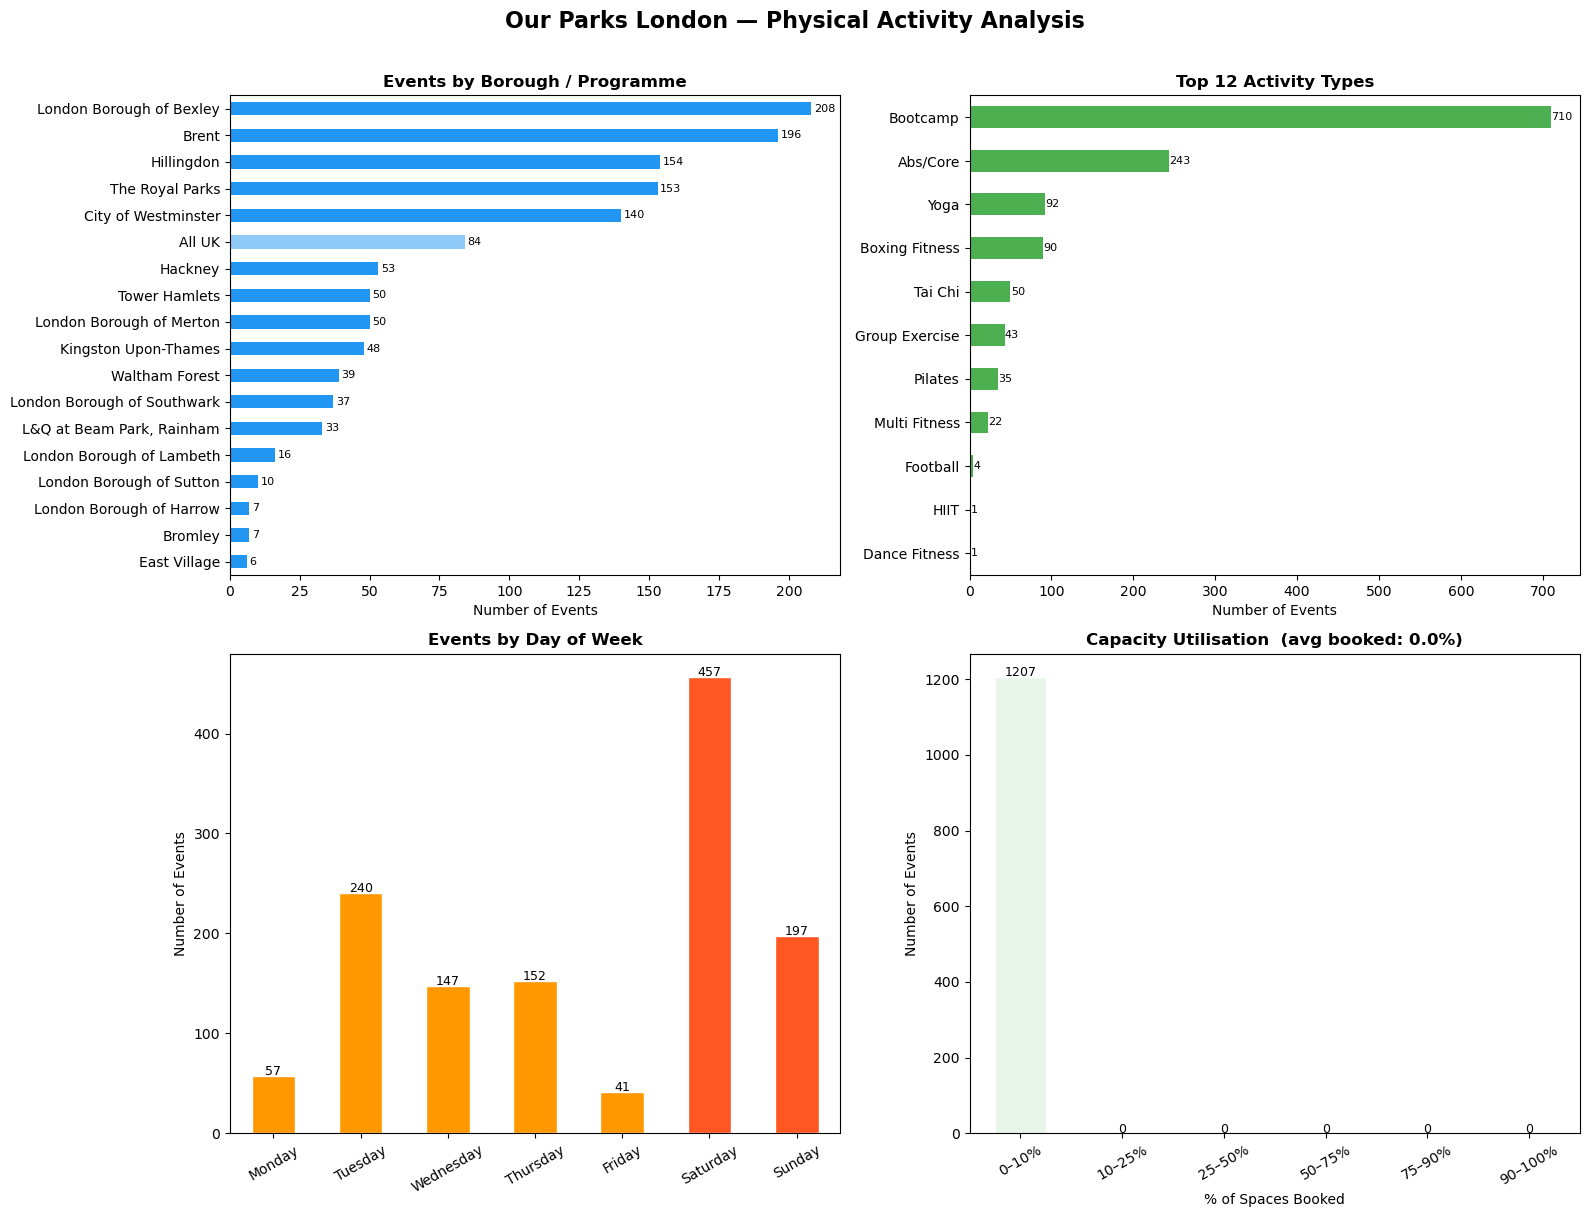

Chart saved to ourparks_analysis.png

── KEY FINDINGS ──────────────────────────────────────────────────
Total active events:        1291
Boroughs/programmes:        18
Unique activity types:      11

Top borough:                London Borough of Bexley (208 events)
Top activity:               Bootcamp (710 events)
Busiest day:                Saturday (457 events)
Busiest hour:               9:00

Avg class size (max cap):   28 people
Avg spaces remaining:       28 per class
Avg capacity used:          0.0%

Most underserved boroughs (fewest events):
  East Village: 6 events
  Bromley: 7 events
  London Borough of Harrow: 7 events
  London Borough of Sutton: 10 events
  London Borough of Lambeth: 16 events


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv("ourparks_london_events.csv", parse_dates=["start_date", "end_date"])

df["start_date"] = pd.to_datetime(df["start_date"], utc=True, errors="coerce")
df["day_of_week"] = df["start_date"].dt.day_name()
df["hour"]        = df["start_date"].dt.hour
df["month"]       = df["start_date"].dt.month_name()
df["capacity_used_pct"] = (
    (df["max_capacity"] - df["remaining_capacity"]) / df["max_capacity"] * 100
).round(1)

DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Our Parks London — Physical Activity Analysis", fontsize=16, fontweight="bold", y=1.01)

# ── 1. Borough breakdown ───────────────────────────────────────────────────
ax1 = axes[0, 0]
borough_counts = df["programme"].value_counts().sort_values()
colours = ["#2196F3" if "all uk" not in p.lower() else "#90CAF9" for p in borough_counts.index]
borough_counts.plot(kind="barh", ax=ax1, color=colours)
ax1.set_title("Events by Borough / Programme", fontweight="bold")
ax1.set_xlabel("Number of Events")
ax1.set_ylabel("")
for i, v in enumerate(borough_counts):
    ax1.text(v + 1, i, str(v), va="center", fontsize=8)

# ── 2. Activity types ──────────────────────────────────────────────────────
ax2 = axes[0, 1]
activity_counts = df["activity"].value_counts().head(12).sort_values()
activity_counts.plot(kind="barh", ax=ax2, color="#4CAF50")
ax2.set_title("Top 12 Activity Types", fontweight="bold")
ax2.set_xlabel("Number of Events")
ax2.set_ylabel("")
for i, v in enumerate(activity_counts):
    ax2.text(v + 0.3, i, str(v), va="center", fontsize=8)

# ── 3. Timing — day of week + hour heatmap ────────────────────────────────
ax3 = axes[1, 0]
day_counts = df["day_of_week"].value_counts().reindex(DAY_ORDER).fillna(0)
bar_colours = ["#FF5722" if d in ["Saturday","Sunday"] else "#FF9800" for d in DAY_ORDER]
day_counts.plot(kind="bar", ax=ax3, color=bar_colours, edgecolor="white")
ax3.set_title("Events by Day of Week", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("Number of Events")
ax3.tick_params(axis="x", rotation=30)
for i, v in enumerate(day_counts):
    ax3.text(i, v + 1, str(int(v)), ha="center", fontsize=9)

# ── 4. Capacity & availability ────────────────────────────────────────────
ax4 = axes[1, 1]
valid = df[df["max_capacity"] > 0].copy()

# % booked distribution
bins = [0, 10, 25, 50, 75, 90, 100]
labels = ["0–10%","10–25%","25–50%","50–75%","75–90%","90–100%"]
valid["booking_band"] = pd.cut(valid["capacity_used_pct"], bins=bins, labels=labels, include_lowest=True)
band_counts = valid["booking_band"].value_counts().reindex(labels).fillna(0)

cap_colours = ["#E8F5E9","#C8E6C9","#A5D6A7","#66BB6A","#388E3C","#1B5E20"]
band_counts.plot(kind="bar", ax=ax4, color=cap_colours, edgecolor="white")
ax4.set_title("Capacity Utilisation Distribution", fontweight="bold")
ax4.set_xlabel("% of Spaces Booked")
ax4.set_ylabel("Number of Events")
ax4.tick_params(axis="x", rotation=30)
for i, v in enumerate(band_counts):
    ax4.text(i, v + 0.5, str(int(v)), ha="center", fontsize=9)

avg_used = valid["capacity_used_pct"].mean()
ax4.axhline(0, color="none")  # spacer
ax4.set_title(f"Capacity Utilisation  (avg booked: {avg_used:.1f}%)", fontweight="bold")

plt.tight_layout()
plt.savefig("ourparks_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to ourparks_analysis.png")

# ── Summary stats ──────────────────────────────────────────────────────────
print("\n── KEY FINDINGS ──────────────────────────────────────────────────")
print(f"Total active events:        {len(df)}")
print(f"Boroughs/programmes:        {df['programme'].nunique()}")
print(f"Unique activity types:      {df['activity'].nunique()}")
print(f"\nTop borough:                {df['programme'].value_counts().index[0]} ({df['programme'].value_counts().iloc[0]} events)")
print(f"Top activity:               {df['activity'].value_counts().index[0]} ({df['activity'].value_counts().iloc[0]} events)")
print(f"Busiest day:                {day_counts.idxmax()} ({int(day_counts.max())} events)")
print(f"Busiest hour:               {df['hour'].mode()[0]}:00")
print(f"\nAvg class size (max cap):   {valid['max_capacity'].mean():.0f} people")
print(f"Avg spaces remaining:       {valid['remaining_capacity'].mean():.0f} per class")
print(f"Avg capacity used:          {avg_used:.1f}%")

underserved = df.groupby("programme").size().sort_values().head(5)
print(f"\nMost underserved boroughs (fewest events):")
for b, c in underserved.items():
    print(f"  {b}: {c} events")